In [347]:
import os
import json
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import joblib

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, r2_score

pd.options.display.float_format = '{:.2f}'.format
os.environ['DYLD_LIBRARY_PATH'] = '/opt/homebrew/opt/libomp/lib'

## 1. Load NIL Data

In [348]:
df_raw = pd.read_csv('nil_data.csv')
df_raw = df_raw[df_raw['value'] > 0]
df_raw = df_raw[df_raw['minsPg'] >= 15]

print(f'Total NIL records: {len(df_raw)}')
print(df_raw['gender'].value_counts())

Total NIL records: 385
gender
MALE      283
FEMALE    102
Name: count, dtype: int64


## 2. Fetch Stats for Every Competition

In [349]:
compids = df_raw['competitionId'].unique()
print(f'Competition IDs: {compids}')

all_stats = []
for cid in compids:
    url = f'https://api.cbbanalytics.com/api/gs/player-agg-stats-public?competitionId={cid}&divisionId=1&scope=season'
    data = requests.get(url).json()
    all_stats.append(pd.DataFrame(data))
    print(f'  cid={cid}: {len(data)} rows')

allstatsdf = pd.concat(all_stats, ignore_index=True)
print(f'Total stats rows: {len(allstatsdf)}')

Competition IDs: [33533 36046 38529 38409 36045]
  cid=33533: 5049 rows
  cid=36046: 5006 rows
  cid=38529: 4723 rows
  cid=38409: 5063 rows
  cid=36045: 4655 rows
Total stats rows: 24496


## 3. Merge

In [351]:
df_merged = df_raw[['competitionId', 'playerId', 'value']].merge(
    allstatsdf, on=['competitionId', 'playerId'], how='left'
)

print(f'Merged rows: {len(df_merged)}')
print(df_merged['gender'].value_counts())

Merged rows: 385
gender
MALE      283
FEMALE    102
Name: count, dtype: int64


## 4. Training Function

Encapsulates the full pipeline for a single gender so we can train both cleanly.

In [352]:
CANDIDATE_FEATURES = [
    # Best all-in-one value metrics
    'rapm', 'orapm', 'drapm',
    'warpP40', 'wsP40', 'owsP40', 'dwsP40',
    'per',
    # Efficiency
    'tsPct', 'efgPct',
    # Production rates
    'ptsScoredPg', 'ptsScoredP40', 'fgaPg',
    'rebPg', 'blkPg', 'blkPct',
    # Playing time (coaches vote with minutes)
    'minsPg',
    # Physical
    'height',
    # Context
    'conf_tier',
]

def train_nil_model(df_gender, gender_label):
    print(f'\n===== {gender_label} =====')
    print(f'Records: {len(df_gender)}')
    print(f'Value range: ${df_gender["value"].min():,.0f} - ${df_gender["value"].max():,.0f}')

    # --- Conference tier: derived from this gender's NIL data ---
    conf_medians = df_gender.groupby('conferenceId')['value'].median()
    top_confs = conf_medians[conf_medians >= conf_medians.quantile(0.70)].index
    mid_confs = conf_medians[
        (conf_medians >= conf_medians.quantile(0.35)) &
        (conf_medians <  conf_medians.quantile(0.70))
    ].index

    def conf_tier(cid):
        if cid in top_confs: return 3
        if cid in mid_confs: return 2
        return 1

    df_gender = df_gender.copy()
    df_gender['conf_tier'] = df_gender['conferenceId'].apply(conf_tier)

    # --- Log transform ---
    df_gender['log_value'] = np.log1p(df_gender['value'])

    # --- Keep only available candidate features ---
    cands = [f for f in CANDIDATE_FEATURES if f in df_gender.columns]
    df_model = df_gender[cands + ['log_value', 'value']].dropna(
        subset=['rapm', 'warpP40', 'log_value']
    ).copy()
    df_model[cands] = df_model[cands].apply(pd.to_numeric, errors='coerce').fillna(0)
    print(f'Training rows after dropna: {len(df_model)}')

    # --- Feature selection via LightGBM importance ---
    probe = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        min_child_samples=10, random_state=42, verbose=-1
    )
    probe.fit(df_model[cands], df_model['log_value'])
    importance = pd.Series(probe.feature_importances_, index=cands).sort_values(ascending=False)
    features = importance[importance >= importance.median()].index.tolist()
    print(f'Selected features: {features}')

    # --- 5-fold CV ---
    X = df_model[features]
    y_log = df_model['log_value']
    y_raw = df_model['value']

    model = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    )
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X, y_log, cv=cv, scoring='r2')
    print(f'5-fold CV R2: {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}')

    # --- Final fit + eval ---
    X_train, X_test, y_train, y_test, _, y_raw_test = train_test_split(
        X, y_log, y_raw, test_size=0.2, random_state=42
    )
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    y_pred_raw = np.expm1(y_pred_log)

    r2  = r2_score(y_test, y_pred_log)
    mae = mean_absolute_error(y_raw_test, y_pred_raw)
    print(f'Test R2  (log scale): {r2:.3f}')
    print(f'Test MAE (dollars):   ${mae:,.0f}')
    print(f'Median actual value:  ${y_raw_test.median():,.0f}')

    # --- Tier thresholds ---
    nil_low  = float(df_model['value'].quantile(0.33))
    nil_high = float(df_model['value'].quantile(0.67))
    print(f'Tiers: Low < ${nil_low:,.0f} | Mid < ${nil_high:,.0f} | High >=')

    # --- Plots ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].scatter(y_test, y_pred_log, alpha=0.4, s=15)
    mn, mx = y_test.min(), y_test.max()
    axes[0].plot([mn, mx], [mn, mx], 'r--')
    axes[0].set_title(f'{gender_label} — Actual vs Predicted  R2={r2:.3f}')
    axes[0].set_xlabel('Actual log(NIL)')
    axes[0].set_ylabel('Predicted log(NIL)')
    axes[1].scatter(y_pred_log, y_test.values - y_pred_log, alpha=0.4, s=15)
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title('Residuals')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residual')
    plt.tight_layout()
    plt.show()

    return {
        'model':        model,
        'features':     features,
        'nil_low':      nil_low,
        'nil_high':     nil_high,
        'top_confs':    list(map(int, top_confs)),
        'mid_confs':    list(map(int, mid_confs)),
    }

## 5. Train Men's Model


===== MALE =====
Records: 283
Value range: $10,000 - $4,000,000
Training rows after dropna: 283
Selected features: ['minsPg', 'rapm', 'ptsScoredPg', 'fgaPg', 'drapm', 'orapm', 'dwsP40', 'owsP40', 'wsP40', 'warpP40']
5-fold CV R2: 0.269 +/- 0.089
Test R2  (log scale): 0.241
Test MAE (dollars):   $607,135
Median actual value:  $480,000
Tiers: Low < $200,480 | Mid < $1,000,000 | High >=


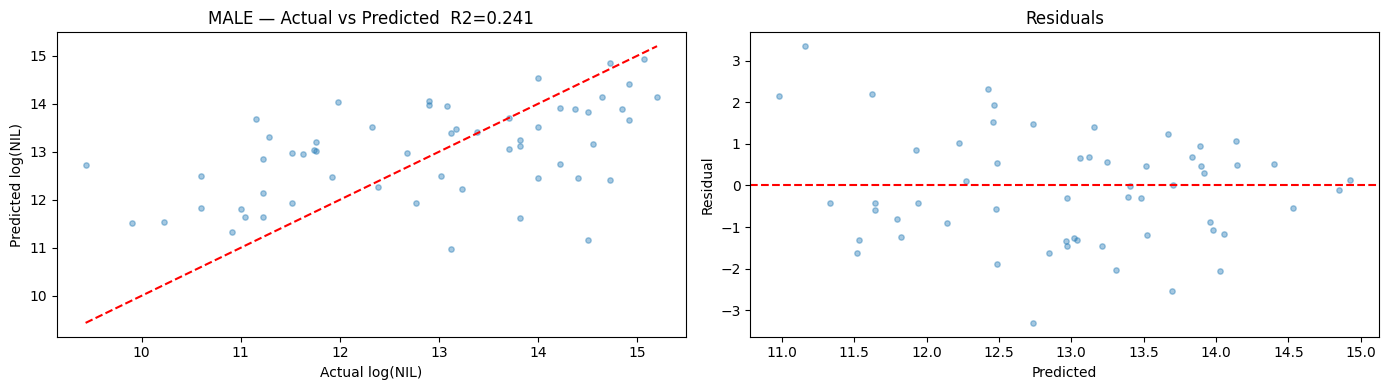

In [353]:
df_male = df_merged[df_merged['gender'] == 'MALE'].copy()
results_male = train_nil_model(df_male, 'MALE')

## 6. Train Women's Model


===== FEMALE =====
Records: 102
Value range: $2,000 - $750,000
Training rows after dropna: 102
Selected features: ['drapm', 'minsPg', 'rapm', 'wsP40', 'orapm', 'tsPct', 'efgPct', 'owsP40', 'warpP40', 'blkPct']
5-fold CV R2: 0.048 +/- 0.194
Test R2  (log scale): 0.039
Test MAE (dollars):   $107,974
Median actual value:  $60,000
Tiers: Low < $41,650 | Mid < $120,000 | High >=


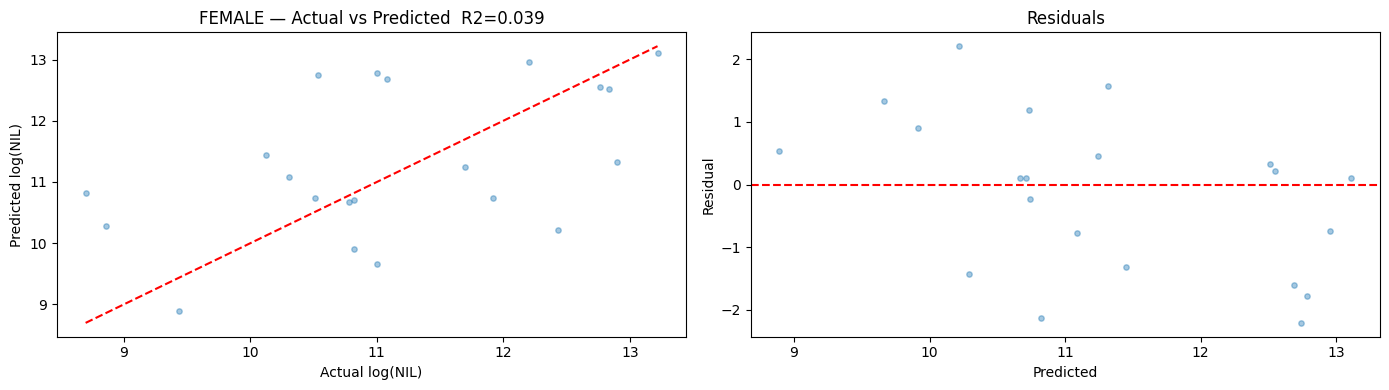

In [354]:
df_female = df_merged[df_merged['gender'] == 'FEMALE'].copy()
results_female = train_nil_model(df_female, 'FEMALE')

## 7. Compare Models

In [355]:
print('=== Men ===');
print(f'  Features: {results_male["features"]}')
print(f'  Tiers: Low < ${results_male["nil_low"]:,.0f}  |  High > ${results_male["nil_high"]:,.0f}')
print()
print('=== Women ===')
print(f'  Features: {results_female["features"]}')
print(f'  Tiers: Low < ${results_female["nil_low"]:,.0f}  |  High > ${results_female["nil_high"]:,.0f}')

=== Men ===
  Features: ['minsPg', 'rapm', 'ptsScoredPg', 'fgaPg', 'drapm', 'orapm', 'dwsP40', 'owsP40', 'wsP40', 'warpP40']
  Tiers: Low < $200,480  |  High > $1,000,000

=== Women ===
  Features: ['drapm', 'minsPg', 'rapm', 'wsP40', 'orapm', 'tsPct', 'efgPct', 'owsP40', 'warpP40', 'blkPct']
  Tiers: Low < $41,650  |  High > $120,000


## 8. Sanity Check — Current Season Players

In [358]:
def predict_players(result, comp_id, names):
    url = f'https://api.cbbanalytics.com/api/gs/player-agg-stats-public?competitionId={comp_id}&divisionId=1&scope=season'
    playerdf = pd.DataFrame(requests.get(url).json())

    top_confs = set(result['top_confs'])
    mid_confs = set(result['mid_confs'])
    playerdf['conf_tier'] = playerdf['conferenceId'].apply(
        lambda c: 3 if c in top_confs else (2 if c in mid_confs else 1)
    )

    test = playerdf[playerdf['fullName'].isin(names)]
    test_X = test[result['features']].apply(pd.to_numeric, errors='coerce').fillna(0)
    preds = np.expm1(result['model'].predict(test_X)).round(0).astype(int)

    for name, pred in zip(test['fullName'].values, preds):
        tier = 'High Value' if pred >= result['nil_high'] else ('Mid Value' if pred >= result['nil_low'] else 'Low Value')
        print(f'  {name}: {tier}  ~${pred:,}')

print('Men (comp 41097):')
predict_players(results_male, 41097, ['Cameron Boozer', 'Darryn Peterson', 'Darius Adams'])

print('\nWomen (comp 41098):')
predict_players(results_female, 41098, ['Azzi Fudd', 'Audi Crooks'])

Men (comp 41097):
  Cameron Boozer: High Value  ~$1,808,846
  Darryn Peterson: High Value  ~$1,341,513
  Darius Adams: Low Value  ~$117,074

Women (comp 41098):
  Azzi Fudd: High Value  ~$458,380
  Audi Crooks: High Value  ~$293,963


## 9. Export Both Models

In [359]:
for gender, result in [('male', results_male), ('female', results_female)]:
    pkl_path  = f'nil_regressor_{gender}.pkl'
    meta_path = f'nil_meta_{gender}.json'

    joblib.dump(result['model'], pkl_path)

    meta = {
        'features':           result['features'],
        'nil_low_threshold':  result['nil_low'],
        'nil_high_threshold': result['nil_high'],
        'conf_tier_top':      result['top_confs'],
        'conf_tier_mid':      result['mid_confs'],
    }
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)

    print(f'Exported: {pkl_path}, {meta_path}')
    print(f'  Features: {result["features"]}')

Exported: nil_regressor_male.pkl, nil_meta_male.json
  Features: ['minsPg', 'rapm', 'ptsScoredPg', 'fgaPg', 'drapm', 'orapm', 'dwsP40', 'owsP40', 'wsP40', 'warpP40']
Exported: nil_regressor_female.pkl, nil_meta_female.json
  Features: ['drapm', 'minsPg', 'rapm', 'wsP40', 'orapm', 'tsPct', 'efgPct', 'owsP40', 'warpP40', 'blkPct']
